In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import plot_model

In [2]:
# Load the data
data = pd.read_csv(r'C:\Users\hugo-\Desktop\Tese_Mestrado\Code\robot_LSTM_data2.csv')

# Display the first few rows of the data
print(data.head())

# Define the number of time steps in each sequence
n_steps = 20

# Function to create sequences from the data
def create_sequences(data, n_steps):
    sequences = []
    for i in range(len(data) - n_steps):
        seq_x = data.iloc[i:i + n_steps, 0].values.astype('float32')  # Features (errors)
        seq_y = data.iloc[i + n_steps, 1:3].values.astype('float32')    # Labels (left and right speeds)
        sequences.append((seq_x, seq_y))
    return sequences

# Create sequences
sequences = create_sequences(data, n_steps)

# Print some sample sequences and their corresponding labels for verification
print("Sample sequences and their corresponding labels:")
for i in range(3):  # Print the first 3 sequences
    print(f"Sequence {i + 1}:")
    print("Input (errors):", sequences[i][0].flatten())
    print("Output (speeds):", sequences[i][1])
    print()

# Split the sequences into input (X) and output (y)
X, y = zip(*sequences)

# Convert evaluated tensors to NumPy arrays
X = np.array(X)
y = np.array(y)

# Reshape X to have three dimensions if it doesn't already
if X.ndim == 2:
    X = X.reshape((X.shape[0], n_steps, 1))

# Verify the shapes
print(f'X shape: {X.shape}')  # Should be (num_sequences, n_steps, num_features)
print(f'y shape: {y.shape}')  # Should be (num_sequences, num_outputs)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

   error  new_left_speed  new_right_speed
0    0.0       69.820833        70.179167
1    0.0       83.820833        56.179167
2    0.0       83.820833        56.179167
3    0.0       83.820833        56.179167
4    0.0       83.820833        56.179167
Sample sequences and their corresponding labels:
Sequence 1:
Input (errors): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Output (speeds): [83.82083  56.179165]

Sequence 2:
Input (errors): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Output (speeds): [83.82083  56.179165]

Sequence 3:
Input (errors): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Output (speeds): [83.82083  56.179165]

X shape: (39634, 20, 1)
y shape: (39634, 2)


In [3]:
# Define the LSTM model using TensorFlow Keras
model = Sequential()
model.add(LSTM(50, input_shape=(n_steps, 1), return_sequences=True))
model.add(Dropout(0.1))  # Add Dropout layer with 20% dropout rate
model.add(LSTM(50, input_shape=(n_steps, 1), return_sequences=False))
model.add(Dropout(0.1))  # Add Dropout layer with 20% dropout rate
model.add(Dense(50, activation='relu'))  # Additional Dense layer with ReLU activation
model.add(Dense(2))  # Output layer for left and right speeds

model.compile(optimizer='adam', loss='mse')
model.summary()

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 20, 50)            10400     
_________________________________________________________________
dropout (Dropout)            (None, 20, 50)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 50)                20200     
_________________________________________________________________
dropout_1 (Dropout)          (None, 50)                0         
_________________________________________________________________
dense (Dense)                (None, 50)                2550      
_________________________________________________________________
dense_1 (Dense)              (None, 2)                 102       
Tota

In [4]:
# Train the model
history = model.fit(X_train, y_train, epochs=60, batch_size=32, validation_data=(X_test, y_test))

Train on 31707 samples, validate on 7927 samples
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Epoch 1/60
31707/31707 [==============================] - 20s 640us/sample - loss: 8246.6860 - val_loss: 5128.9791
Epoch 2/60
31707/31707 [==============================] - 20s 621us/sample - loss: 5221.4565 - val_loss: 4933.0583
Epoch 3/60
31707/31707 [==============================] - 19s 600us/sample - loss: 5340.0163 - val_loss: 6254.8934
Epoch 4/60
31707/31707 [==============================] - 20s 622us/sample - loss: 6239.8575 - val_loss: 6193.4598
Epoch 5/60
31707/31707 [==============================] - 19s 609us/sample - loss: 6153.2364 - val_loss: 6138.8317
Epoch 6/60
31707/31707 [==============================] - 19s 607us/sample - loss: 6121.7391 - val_loss: 6092.9300
Epoch 7/60
31707/31707 [==============================] - 20s 634us/sample - loss: 6056.7038 - val_loss: 6073.1812
Epoch 8/60
31707/31707 [============================

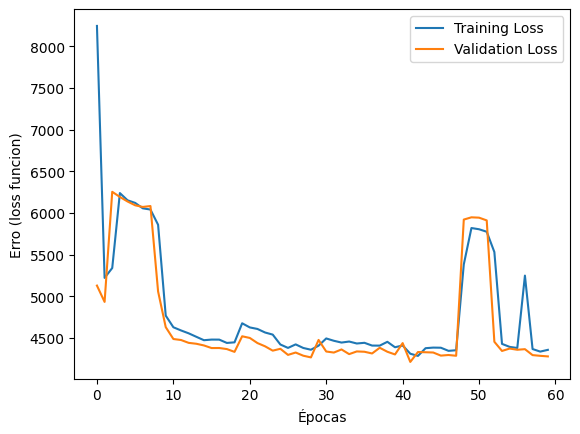

In [5]:
# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Épocas')  # X-axis label
plt.ylabel('Erro (loss funcion)')    # Y-axis label
plt.legend()
plt.show()

In [5]:
# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')
model.save(r'C:\Users\hugo-\Desktop\Tese_Mestrado\Code\my_lstm_model4.h5')

7915/7915 [==============================] - 4s 485us/sample - loss: 2716.6638
Test loss: 2716.6637788773787


In [22]:
# Prepare the input data in the same format as the training data
input_data = np.array([[0,0,0,0,0,0,0,0,0,0,0,3150,3150,3150,6000]])  # Ensure input_data has the shape (1, 3)
# Reshape the input_data to match the LSTM model input shape
input_data = input_data.reshape((1, 15, 1))  # Shape should be (batch_size, n_steps, input_dim)
        
# Use the model to predict new speeds
new_speeds = model.predict(input_data)
print(new_speeds)

[[  4.414547 134.60234 ]]
